In [32]:
import pandas as pd
import json

# File path to your JSON data
file_path = "../Hyperparameters_search/Hyperparameters_search_UAE_final/intermediate_results4.jsonl"  # Update with the actual file path

# Read the JSON file line by line and store each JSON object in a list
data_list = []
with open(file_path, "r") as file:
    for line in file:
        try:
            data_list.append(json.loads(line.strip()))
        except:
            continue

# Normalize JSON data to a Pandas DataFrame
df = pd.json_normalize(data_list, sep='_')

# Display the DataFrame
#import ace_tools as tools
#tools.display_dataframe_to_user(name="Hyperparameter Search Results", dataframe=df)

import numpy as np

# Deal with runs that haven't converged
df.loc[df["metrics_observed_rmse"] == 0, df.columns[df.columns.str.startswith("metrics_")]] = np.nan
df['Converged'] = (df.metrics_observed_rmse==df.metrics_observed_rmse)

metrics_mask = [('metrics' in elt) for elt in df.columns]
metrics = df.columns[metrics_mask]

df = df[df.training_time > 50]
#df.loc[df.hyperparameters_pre_imputation!=df.hyperparameters_pre_imputation,'hyperparameters_pre_imputation'] = False

df

,training_time,hyperparameters_run_nb,hyperparameters_alpha,hyperparameters_beta,hyperparameters_sigma,hyperparameters_model_p,hyperparameters_pre_impute,hyperparameters_detach,hyperparameters_dae,hyperparameters_latent_dim,...,metrics_observed_uncertainty_error_corr,metrics_missing_rmse,metrics_missing_nll,metrics_missing_elbo,metrics_missing_coverage,metrics_missing_uncertainty_error_corr,metrics_latent_latent_ks,metrics_latent_latent_log_prob,metrics_reconstruction_overall_coverage,Converged
0,381.484260,1,0.01,0.01,0.001,0.3,True,True,True,3,...,0.082324,0.175059,-149.622446,-58866.494742,0.036527,0.186558,NaN,-0.727770,0.073862,True
1,354.826673,1,0.01,0.01,0.001,0.3,True,True,True,3,...,0.067449,0.301066,409.330000,-61457.583907,0.028618,0.128005,NaN,-0.714863,0.070000,True
2,378.468652,1,0.01,0.01,0.001,0.3,True,True,True,3,...,0.032704,0.340680,1961.595270,-60951.942926,0.023239,-0.144376,NaN,-2.458578,0.041799,True
3,517.698003,1,0.01,0.01,0.001,0.3,True,True,True,3,...,0.036070,0.427389,6343.057848,-62376.768785,0.023084,-0.048566,NaN,-4.499810,0.039735,True
4,263.865295,1,0.01,0.01,0.001,0.3,True,True,True,3,...,-0.073808,0.609297,21343.468992,-77564.058836,0.009511,0.115900,NaN,-41.587073,0.020952,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,454.287645,4,1.00,0.01,0.001,0.3,True,False,True,6,...,0.140798,0.626094,30774.814311,-105502.376811,0.454950,0.492639,NaN,-3.838718,0.497989,True
574,568.307825,1,0.50,0.01,0.001,0.3,True,False,True,3,...,-0.145269,0.194061,-207.918059,-38168.714754,0.434338,0.335516,NaN,-0.653216,0.653915,True
575,293.736737,4,1.00,0.01,0.001,0.3,True,False,True,6,...,0.140710,0.461362,10183.979211,-59248.916711,0.624536,0.589119,NaN,-2.090398,0.679630,True
576,552.882064,1,0.50,0.01,0.001,0.3,True,False,True,3,...,-0.052178,0.340848,3527.585217,-43908.971935,0.367075,0.451477,NaN,-1.209447,0.528836,True


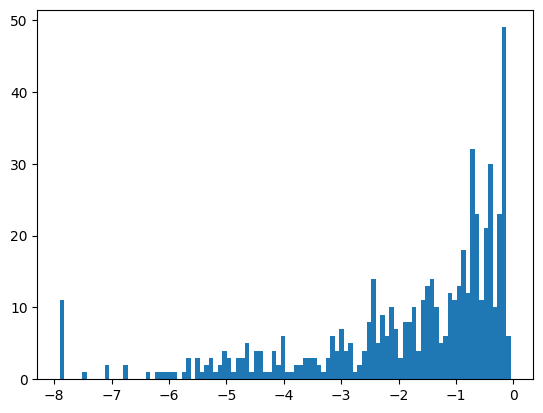

In [33]:
df = df[df.metrics_latent_latent_log_prob>-10]
plt.hist(df.metrics_latent_latent_log_prob.values, bins = 100);

In [54]:
hyperparameters = [elt for elt in df.columns if elt.split('_')[0]=='hyperparameters']
metrics = [elt for elt in df.columns if elt.split('_')[0]=='metrics']
hyperparameters.pop(0)

hyperparameters, metrics

(['hyperparameters_alpha',
  'hyperparameters_beta',
  'hyperparameters_sigma',
  'hyperparameters_model_p',
  'hyperparameters_pre_impute',
  'hyperparameters_detach',
  'hyperparameters_dae',
  'hyperparameters_latent_dim',
  'hyperparameters_p_dataset'],
 ['metrics_observed_rmse',
  'metrics_observed_nll',
  'metrics_observed_elbo',
  'metrics_observed_coverage',
  'metrics_observed_uncertainty_error_corr',
  'metrics_missing_rmse',
  'metrics_missing_nll',
  'metrics_missing_elbo',
  'metrics_missing_coverage',
  'metrics_missing_uncertainty_error_corr',
  'metrics_latent_latent_ks',
  'metrics_latent_latent_log_prob',
  'metrics_reconstruction_overall_coverage'])

In [ ]:
def new_hue(df, hue1, hue2):

    

In [102]:
df = df[df.hyperparameters_detach == False]

In [107]:
x = 'hyperparameters_latent_dim'
hue = 'hyperparameters_sigma'
for metric in metrics_use_mean_z:
    fig, ax = plt.subplots(2,2, figsize = (10,10))
    for i,p in enumerate([0.1,0.3,0.5,0.7]):
        sns.boxplot(df[df.hyperparameters_p_dataset==p],
                    y = metric,
                    x = x,
                    hue = hue,
                    ax = ax[i%2,i//2],
                    legend = (i==2))
        ax[i%2,i//2].set_title(f'Dataset missingness ratio : {p}')
    #plt.show()
    name = f'hyperparameter_search_27_03/2_params_{x}_{hue}_metric_{metric}.png'
    plt.tight_layout();
    plt.savefig(name)
    plt.clf()

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparam = "hyperparameters_p_dataset"

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 'metrics_observed_uncertainty_error_corr', 'metrics_latent_latent_log_prob', 
                       'metrics_missing_rmse', 'metrics_missing_coverage',  'metrics_missing_uncertainty_error_corr', 'metrics_reconstruction_overall_coverage']

mask_vals = {}
for hue in hyperparameters:
    print(hue)

    name = f'hyperparameter_search_27_03/metric_{hyperparam}' if not hue else f'hyperparameter_search_27_03/metric_{hyperparam}_hue_{hue}'
    title = f'{hue}'
    
    #hue = 'hyperparameters_alpha'
    fig, ax = plt.subplots(4,2, figsize=(12,12), sharex = True)
    
    #mask = (df.hyperparameters_alpha < 10) if hue else (df.hyperparameters_alpha == 0.1)
    mask = (df.hyperparameters_alpha == df.hyperparameters_alpha)
    for key in mask_vals.keys():
        mask = mask & (df[key] == mask_vals[key])
        name += f'_mask_{key}_{mask_vals[key]}'
        title += f' with {key} = {mask_vals[key]}'
    for i,metric in enumerate(metrics_use_mean_z):
           #ax[i%3, i//3].set_yscale('log')
        sns.boxplot(df[mask], y = metric,    
                x = hyperparam,
                hue = hue,
                ax = ax[i%4, i//4], legend = (i==4+1));
        if i==4+1:
            sns.move_legend(ax[i%4, i//4], "upper left", bbox_to_anchor=(1, 1))
        if metric.split('_')[-1] == 'rmse':
            ax[i%4, i//4].set_yscale('log')
        #try:
        #    sns.move_legend(ax[i%4, i//4], "upper left", bbox_to_anchor=(1, 1))
        #except ValueError:
        #    pass
    #fig.suptitle(title, y=0.92)
    #plt.show()
    plt.tight_layout();
    plt.savefig(name + '.png')
    plt.clf()


hyperparameters_alpha
hyperparameters_beta
hyperparameters_sigma
hyperparameters_model_p
hyperparameters_pre_impute
hyperparameters_detach
hyperparameters_dae
hyperparameters_latent_dim
hyperparameters_p_dataset


<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/665671747.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(df[mask], y = metric,
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/665671747.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(df[mask], y = metric,
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/665671747.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(df[mask], y = metric,
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/665671747.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(df[mask], y = metric,


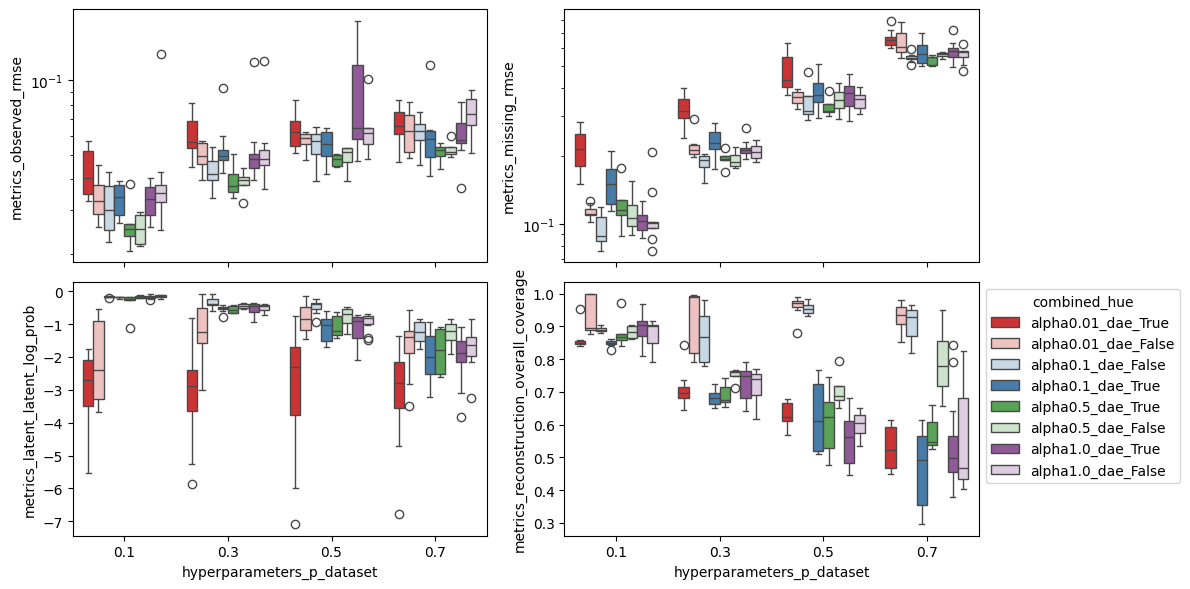

<Figure size 640x480 with 0 Axes>

In [128]:
hue1 = 'hyperparameters_alpha'
hue2 = 'hyperparameters_dae'

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_latent_latent_log_prob', 
                       'metrics_missing_rmse', 'metrics_reconstruction_overall_coverage']

df = df.sort_values(by = 'hyperparameters_alpha')


# Create the combined hue column
#new_hue_name = ('_').join(hue1.split('_')[1:]) + ('_').join(hue2.split('_')[1:])
df['combined_hue'] = ('_').join(hue1.split('_')[1:]) + df[hue1].astype(str) + '_' + ('_').join(hue2.split('_')[1:]) + '_' + df[hue2].astype(str)

# Generate the custom palette
custom_palette = create_custom_palette(df, hue1, hue2)

N = len(metrics_use_mean_z)//2

fig, ax = plt.subplots(N,2, figsize=(12,N*3), sharex = True)


for i,metric in enumerate(metrics_use_mean_z):
       #ax[i%3, i//3].set_yscale('log')
    sns.boxplot(df[mask], y = metric,    
            x = hyperparam,
            hue = 'combined_hue',
            palette = custom_palette,
            ax = ax[i%N, i//N], legend = (i==N+1));
    if i==N+1:
        sns.move_legend(ax[i%N, i//N], "upper left", bbox_to_anchor=(1, 1))
    if metric.split('_')[-1] == 'rmse':
        ax[i%N, i//N].set_yscale('log')
    #try:
    #    sns.move_legend(ax[i%4, i//4], "upper left", bbox_to_anchor=(1, 1))
    #except ValueError:
    #    pass
#fig.suptitle(title, y=0.92)
#plt.show()
name = f'hyperparameter_search_27_03/2_hues_{hue1}_{hue2}'

plt.tight_layout();
plt.savefig(name + '.png')
plt.show()
plt.clf()

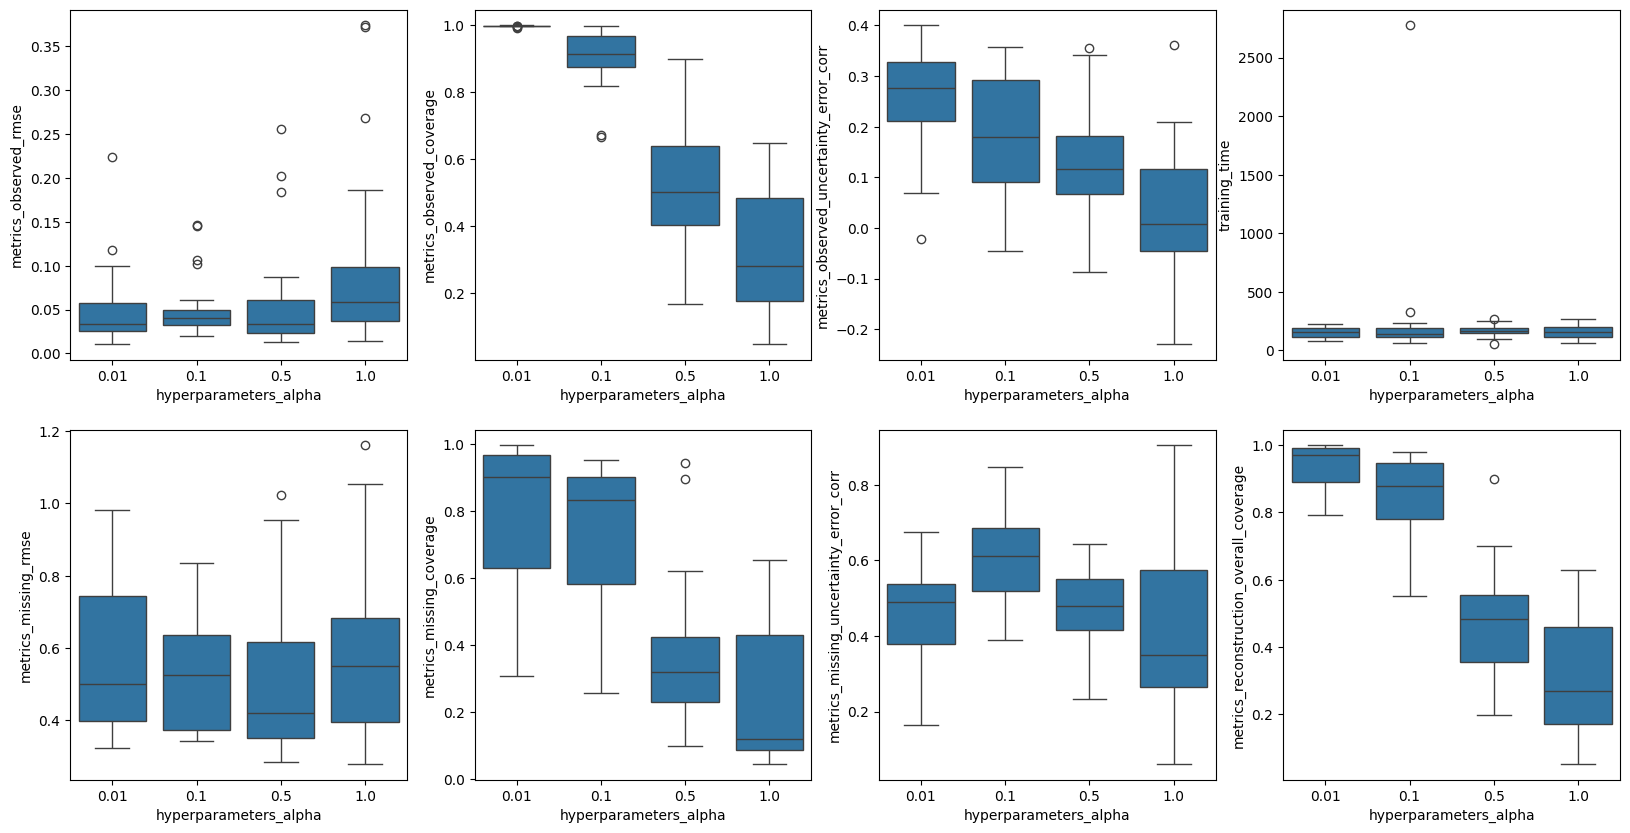

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_use_mean_z = ['metrics_observed_rmse', 'metrics_observed_coverage', 
       'metrics_observed_uncertainty_error_corr','training_time',
       'metrics_missing_rmse','metrics_missing_coverage', 
       'metrics_missing_uncertainty_error_corr','metrics_reconstruction_overall_coverage']
fig, ax = plt.subplots(2,4, figsize=(20,10))
mask = (df.hyperparameters_pre_imputation==False)
for i,metric in enumerate(metrics_use_mean_z):
    sns.boxplot(df[mask], y = metric,    
                x = "hyperparameters_alpha", 
                ax = ax[i//4, i%4]);
#ax[0, 0].set_yscale('log')
#ax[1, 0].set_yscale('log')

{'latent_dim3_sigma_0.001': (0.9682352941176471, 0.7305882352941176, 0.7329411764705882), 'latent_dim3_sigma_0.01': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745), 'latent_dim6_sigma_0.001': (0.7647058823529411, 0.848235294117647, 0.916470588235294), 'latent_dim6_sigma_0.01': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804)}


/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/2752329133.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['combined_hue'] = ('_').join(hue1.split('_')[1:]) + df[hue1].astype(str) + '_' + ('_').join(hue2.split('_')[1:]) + '_' + df[hue2].astype(str)


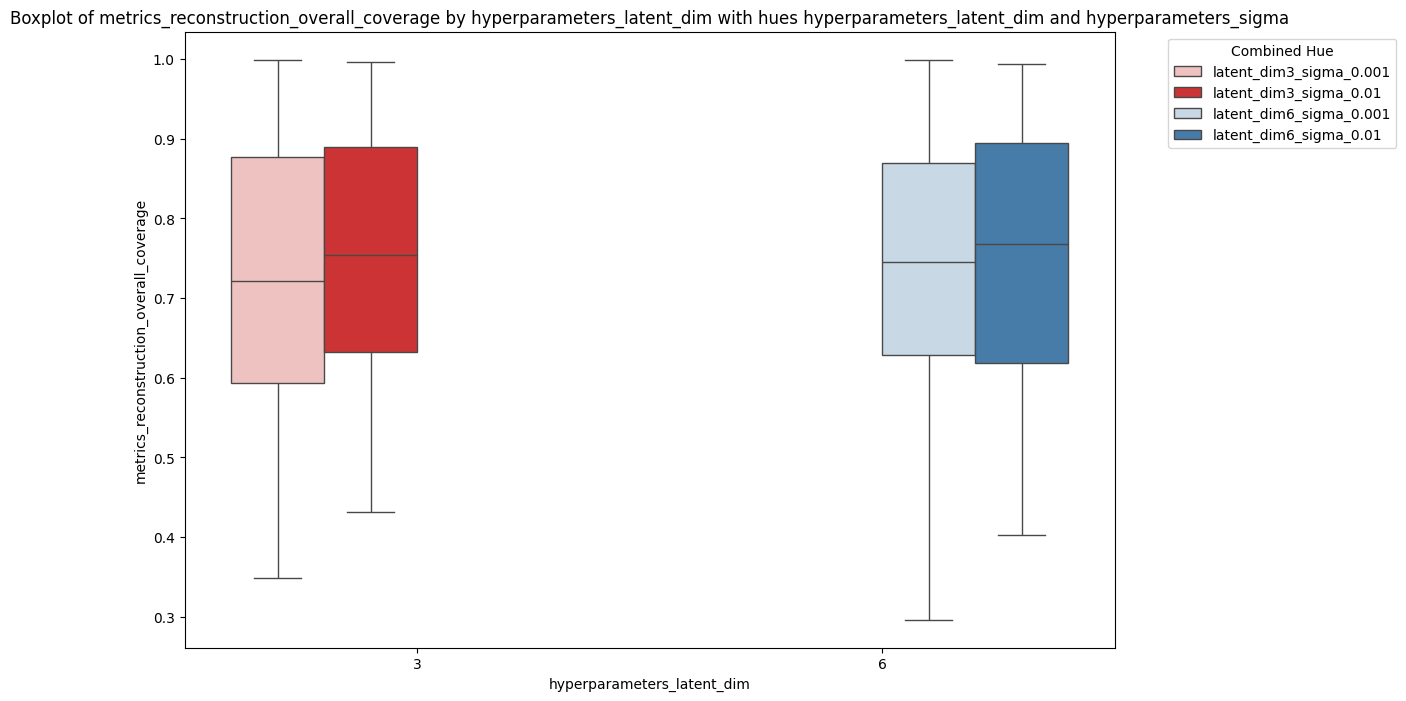

In [114]:
import seaborn as sns
import matplotlib.colors as mcolors

def create_custom_palette(df, hue1, hue2):
    """
    Create a custom palette mapping combined hue levels to specific colors.

    Parameters:
    - df: DataFrame containing the data.
    - hue1: Column name for the primary hue (base color categories).
    - hue2: Column name for the secondary hue (intensity variations).

    Returns:
    - palette: Dictionary mapping combined hue levels to RGB tuples.
    """
    # Extract unique values for hue mapping
    unique_hue1 = sorted(df[hue1].dropna().unique())
    unique_hue2 = sorted(df[hue2].dropna().unique())

    # Generate base colors from a categorical palette
    base_palette = sns.color_palette("Set1", n_colors=len(unique_hue1))

    # Create a mapping of (hue1 -> base color)
    hue1_to_color = {val: base_palette[i] for i, val in enumerate(unique_hue1)}

    # Initialize the palette dictionary
    palette = {}

    # Generate lighter shades for each combination of hue1 and hue2
    for hue1_val in unique_hue1:
        base_color = hue1_to_color[hue1_val]
        for i, hue2_val in enumerate(unique_hue2):
            # Adjust the lightness by blending with white
            lightness_factor = 0.3 + (0.7 * i / (len(unique_hue2) - 1))
            shaded_color = mcolors.to_rgb(base_color)
            shaded_color = [lightness_factor * c + (1 - lightness_factor) for c in shaded_color]
            name = ('_').join(hue1.split('_')[1:]) + hue1_val.astype(str) + '_' + ('_').join(hue2.split('_')[1:]) + '_' + hue2_val.astype(str)
            palette[name] = tuple(shaded_color)

    return palette


import matplotlib.pyplot as plt
import seaborn as sns

# Define your variables
#x = 'your_x_variable'
y = metric
hue1 = 'hyperparameters_latent_dim'
hue2 = 'hyperparameters_sigma'

# Create the combined hue column
#new_hue_name = ('_').join(hue1.split('_')[1:]) + ('_').join(hue2.split('_')[1:])
df['combined_hue'] = ('_').join(hue1.split('_')[1:]) + df[hue1].astype(str) + '_' + ('_').join(hue2.split('_')[1:]) + '_' + df[hue2].astype(str)

# Generate the custom palette
custom_palette = create_custom_palette(df, hue1, hue2)
print(custom_palette)

# Plot using Seaborn boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x=x, y=y, hue='combined_hue', palette=custom_palette)
plt.title(f'Boxplot of {y} by {x} with hues {hue1} and {hue2}')
plt.legend(title='Combined Hue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_24691/2924481842.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['combined_hue'] = ('_').join(hue1.split('_')[1:]) + df[hue1].astype(str) + '_' + ('_').join(hue2.split('_')[1:]) + '_' + df[hue2].astype(str)


IndexError: index 2 is out of bounds for axis 0 with size 2

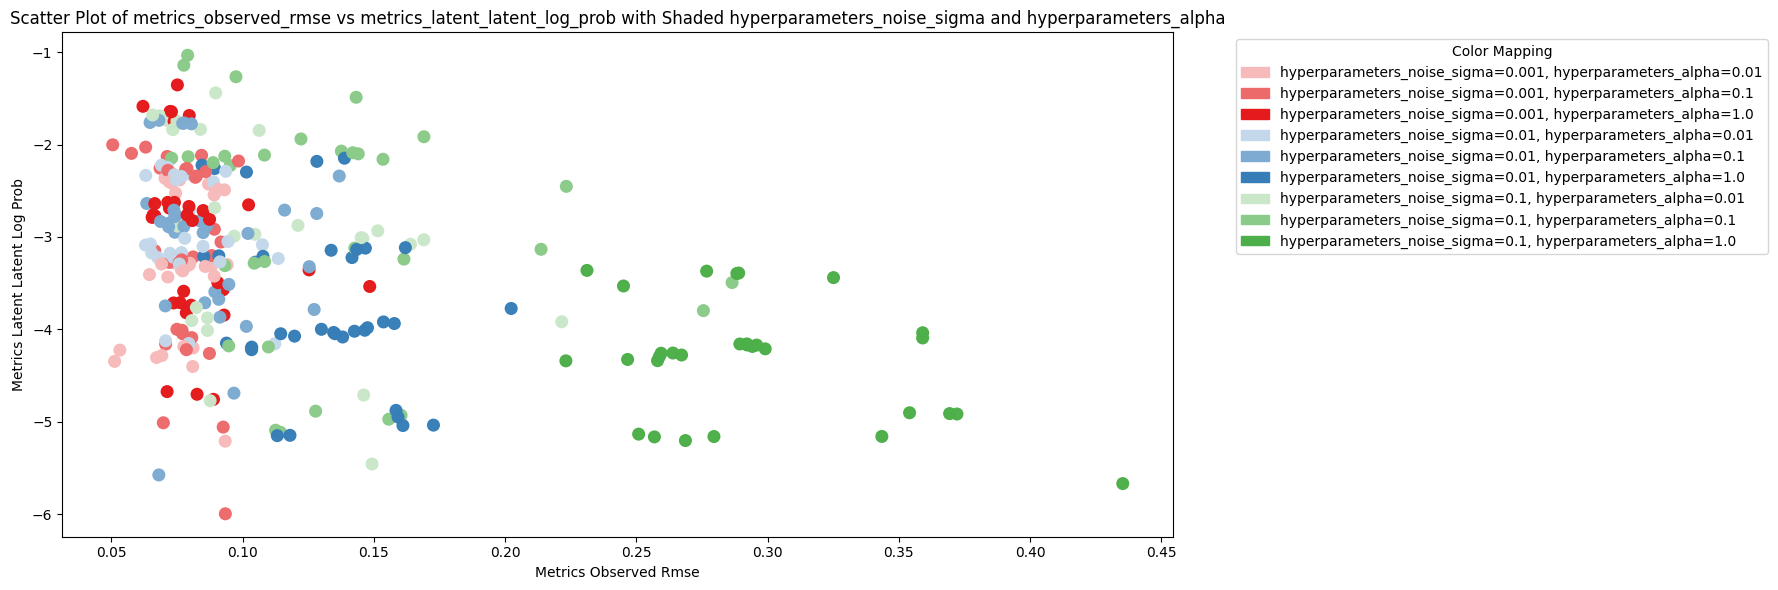

In [209]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_latent_latent_log_prob', 
    hue1='hyperparameters_noise_sigma', 
    hue2='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.3)
)


In [170]:
df_p03_good = df_p03[df_p03.good_results]
df_p03_bad = df_p03[~df_p03.good_results]

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_75110/2238119828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_p03['good_results'] = (df_p03.metrics_observed_rmse < .12) & (df_p03.metrics_latent_latent_log_prob > -2.3)


<Axes: xlabel='hyperparameters_noise_sigma', ylabel='hyperparameters_alpha'>

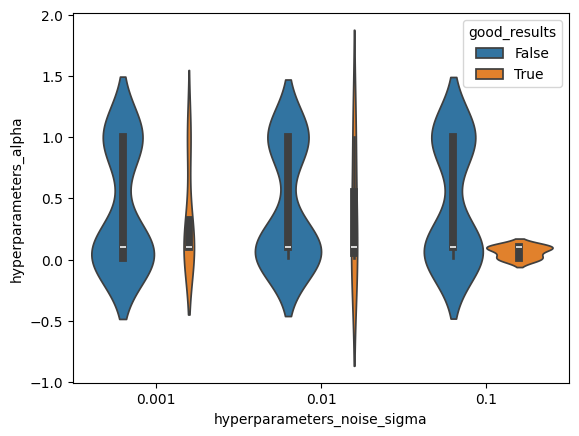

In [165]:
df_p03 = df[df.hyperparameters_p_dataset == 0.3]
df_p03['good_results'] = (df_p03.metrics_observed_rmse < .12) & (df_p03.metrics_latent_latent_log_prob > -2.3)

sns.violinplot(df_p03,
            x = 'hyperparameters_noise_sigma',
            y = 'hyperparameters_alpha',
            hue = 'good_results')

In [ ]:
mask = df.hyperparameters_p_dataset == 0.3
good_results = (df.metrics_observed_rmse > .12) & (df.metrics_latent_latent_log_prob > -2.3)

sns.scatterplot(df[mask])

In [ ]:
df

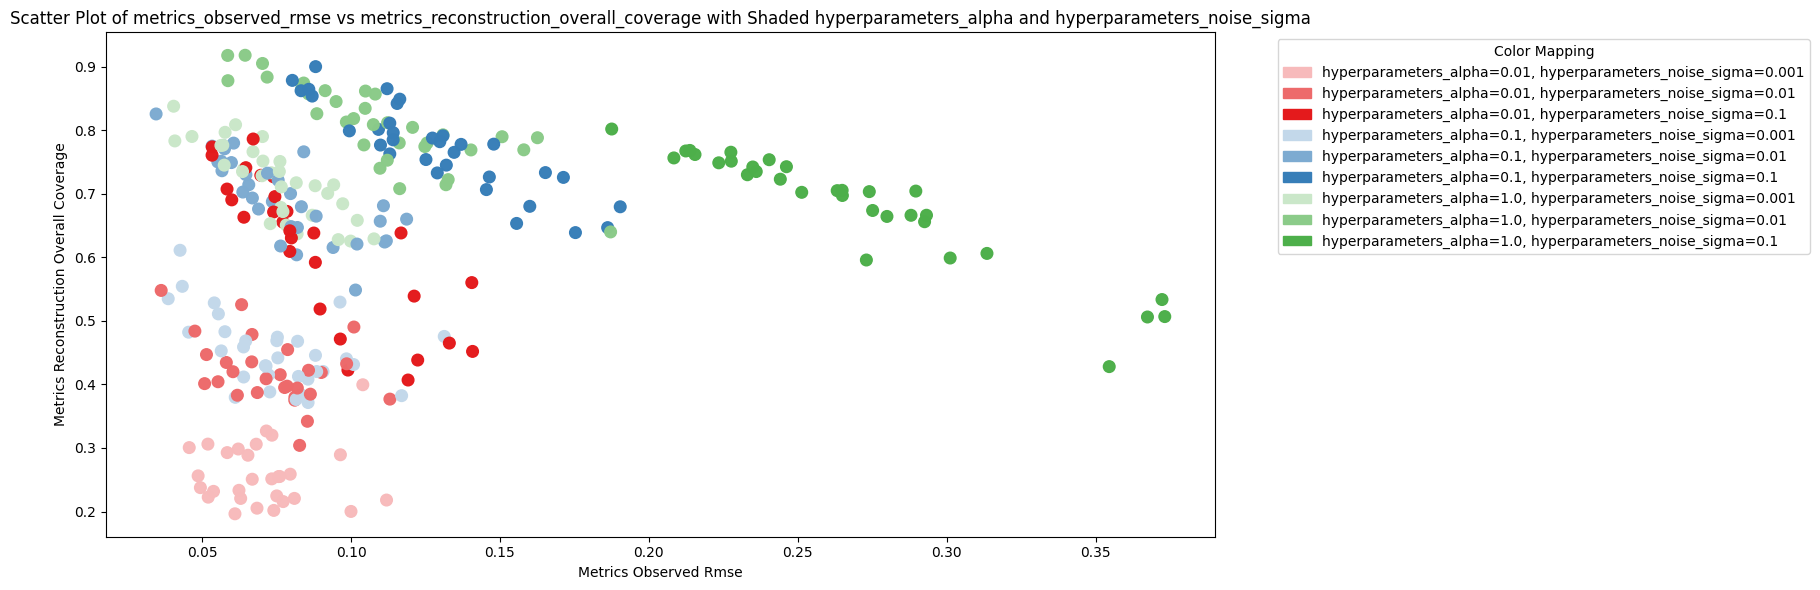

In [210]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_reconstruction_overall_coverage', 
    hue2='hyperparameters_noise_sigma', 
    hue1='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.7)
)


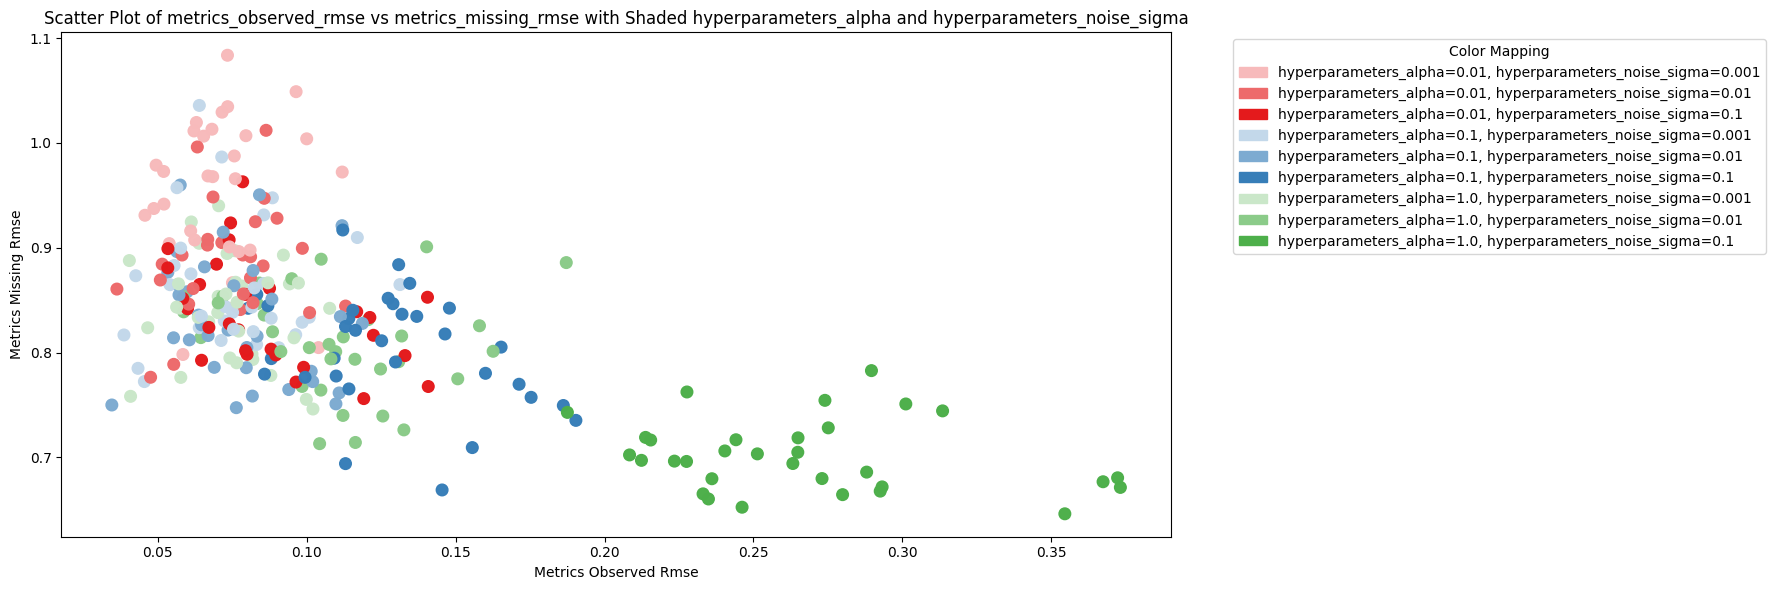

In [211]:
plot_scatter_with_shaded_hues(
    df=df, 
    x='metrics_observed_rmse', 
    y='metrics_missing_rmse', 
    hue2='hyperparameters_noise_sigma', 
    hue1='hyperparameters_alpha',
    mask=(df.hyperparameters_p_dataset == 0.7)
)


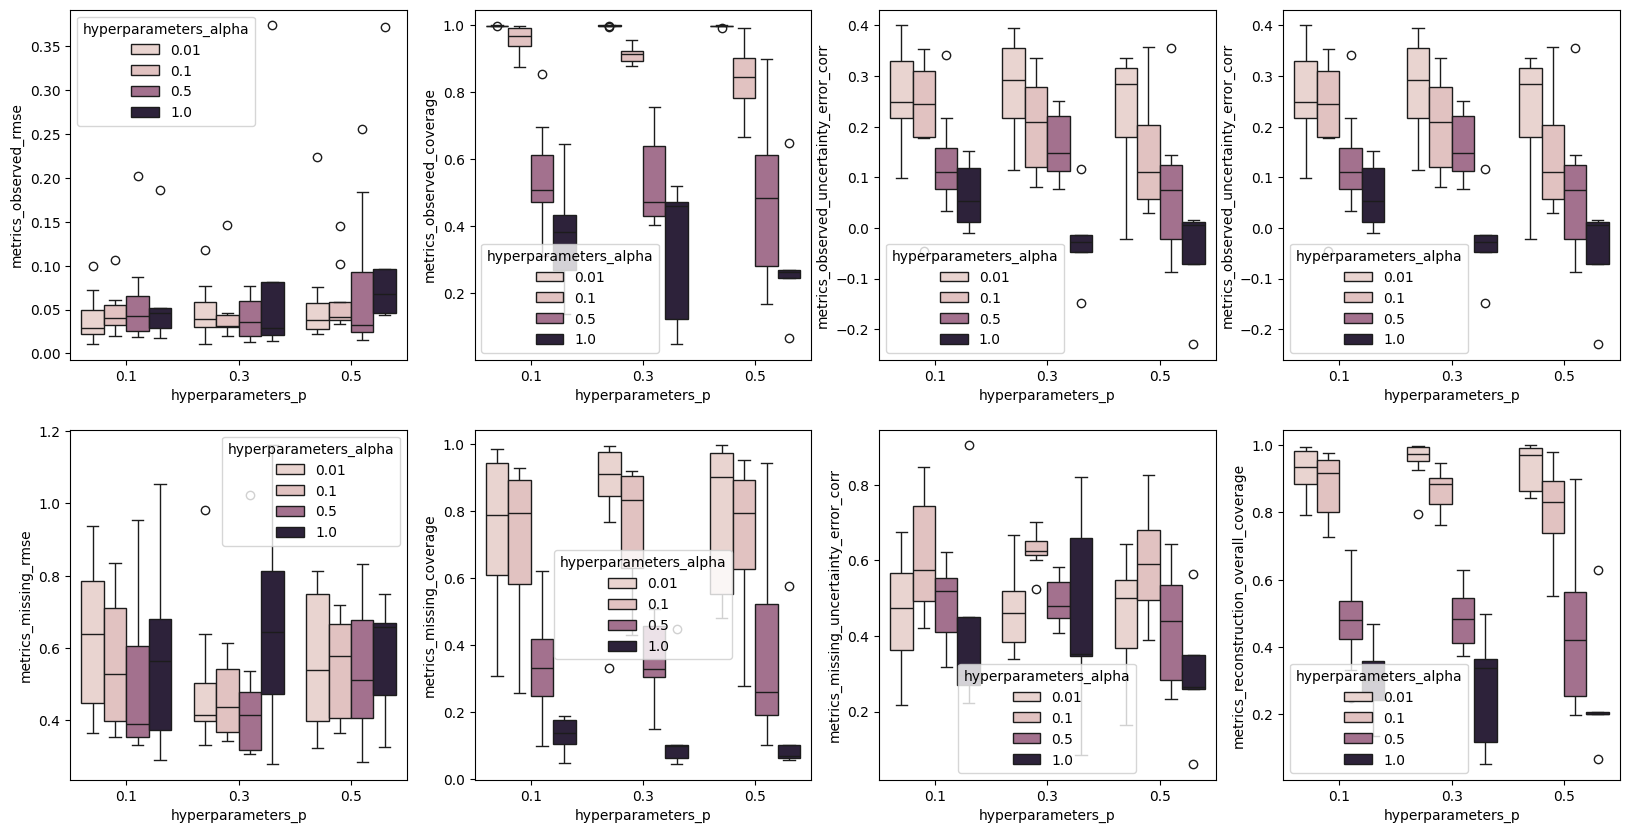

ValueError: Could not interpret value `hyperparameters_p_dataset` for `x`. An entry with this name does not appear in `data`.

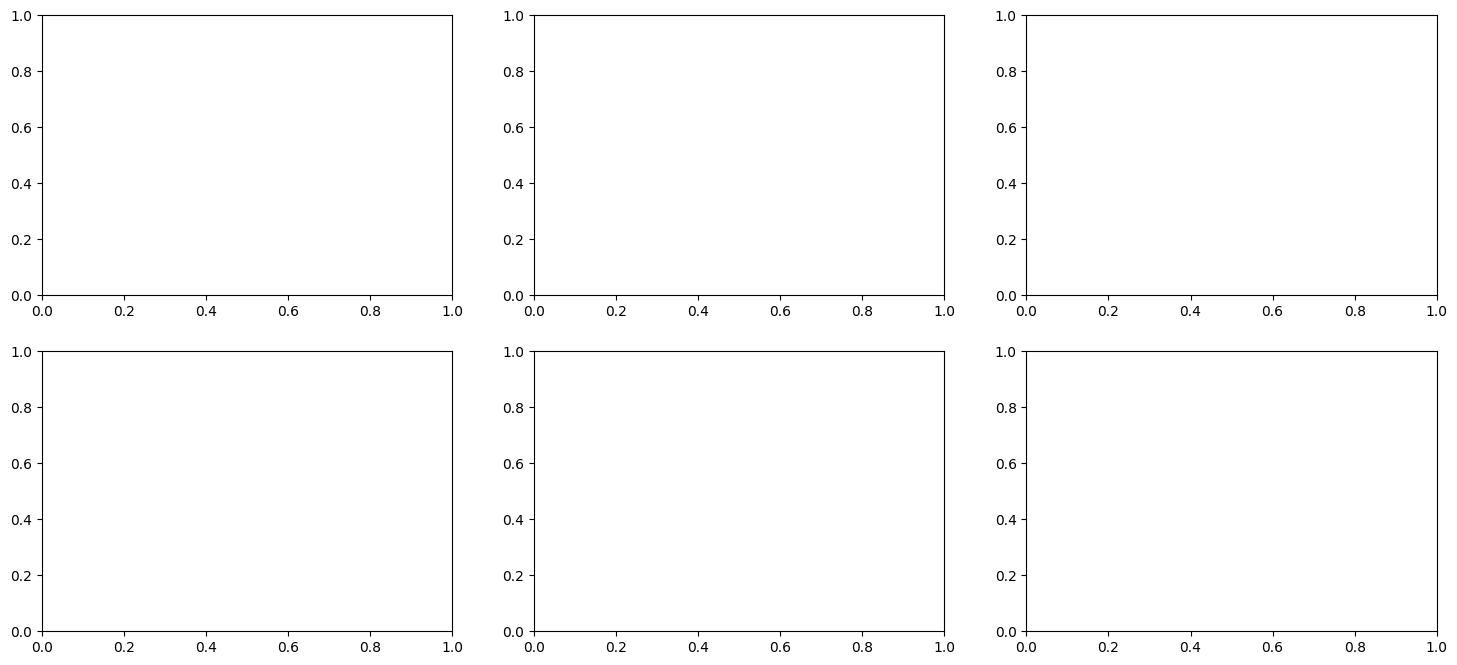

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics in a logical order
metrics = [
    'metrics_observed_coverage', 
    'metrics_missing_coverage', 
    'metrics_reconstruction_overall_coverage',
    'metrics_observed_rmse', 
    'metrics_missing_rmse', 
    'metrics_latent_latent_log_prob'
]

# Extract hyperparameter columns
hyperparams = df.keys()[2:7].values

# Use a Seaborn color palette (can also try 'deep', 'pastel', 'muted', 'Set2', etc.)
palette = sns.color_palette('tab10', n_colors=4)

# Iterate over each hyperparameter and generate plots
for hyperparam in hyperparams:
           
       fig, axes = plt.subplots(2, 3, figsize=(18, 8))
       handles, labels = None, None

       axes = axes.flatten()  # Flatten for easy indexing
       
       for i, metric in enumerate(metrics):
              
              boxplot = sns.boxplot(
              data=df, 
              x='hyperparameters_p_dataset', 
              y=metric, 
              hue=hyperparam, 
              ax=axes[i],
              palette=palette
              )

              if handles is None or labels is None:
                     handles, labels = boxplot.get_legend_handles_labels()
              axes[i].legend_.remove();  # Remove individual legends

              axes[i].set_title(metric.replace('_', ' ').title());  # Improve titles

       # Add a single legend on the side
       fig.legend(handles, labels, loc='center right', title=hyperparam.replace('_', ' ').title());
       plt.tight_layout(rect=[0, 0, 0.85, 1]);  # Adjust layout to fit legend
       plt.show();
       #axes[i].legend(title=hyperparam, loc='best')  # Better legend placement

    #plt.tight_layout()  # Adjust layout for better spacing
    #plt.show()

sns.boxplot(
       data=df, 
       x='hyperparameters_p_dataset', 
       y=metric, 
       hue=hyperparam, 
       ax=axes[i],
       palette=palette
       )


<Axes: >

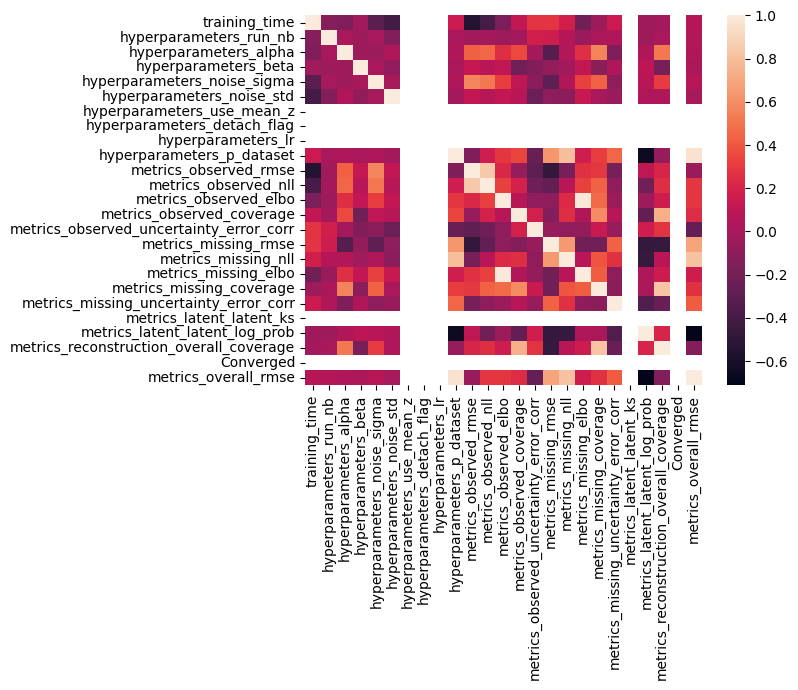

In [214]:
sns.heatmap(df.corr())

<Axes: xlabel='hyperparameters_p_dataset', ylabel='metrics_missing_coverage'>

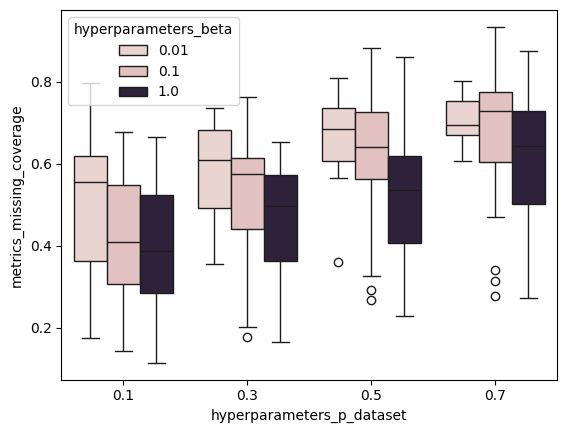

In [15]:
import seaborn as sns

sns.boxplot(df,
            x = 'hyperparameters_p_dataset',
            y = 'metrics_missing_coverage',
            hue = 'hyperparameters_beta')

<Axes: xlabel='metrics_missing_coverage', ylabel='metrics_missing_rmse'>

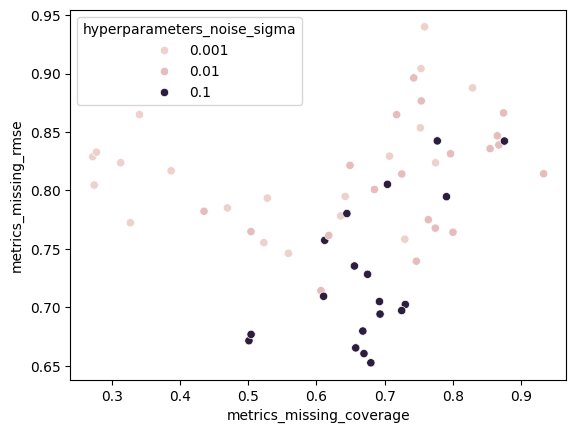

In [16]:
p = 0.7

sns.scatterplot(df[df.hyperparameters_p_dataset==p],
                x = 'metrics_missing_coverage',
                y = 'metrics_missing_rmse',
                hue = 'hyperparameters_noise_sigma'
                )